In [3]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 8.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 5.1 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.neural_network import MLPClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings

In [2]:
warnings.filterwarnings('ignore')

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
arrhythmia_df = pd.read_csv('C:/Users/ASUS/Documents/Aarogya/FastAPI/datasets/Arrhythmia Database.csv')
heart_disease_df = pd.read_csv('C:/Users/ASUS/Documents/Aarogya/FastAPI/datasets/heart-disease-dataset.csv')
coronary_df = pd.read_csv('C:/Users/ASUS/Documents/Aarogya/FastAPI/datasets/CHDdata.csv')

In [5]:
print(f"✅ Arrhythmia Dataset: {arrhythmia_df.shape}")
print(f"✅ Heart Disease Dataset: {heart_disease_df.shape}")
print(f"✅ Coronary Heart Disease Dataset: {coronary_df.shape}")

✅ Arrhythmia Dataset: (175729, 34)
✅ Heart Disease Dataset: (1190, 12)
✅ Coronary Heart Disease Dataset: (462, 10)


In [11]:
def explore_dataset(df, name, target_col):
    print(f"\n--- {name} Dataset Analysis ---")
    print(f"Shape: {df.shape}")
    print(f"Missing values: {df.isnull().sum().sum()}")
    
    if target_col in df.columns:
        print(f"Target distribution:")
        print(df[target_col].value_counts(normalize=True))
    
    return df

arrhythmia_df = explore_dataset(arrhythmia_df, "Arrhythmia", "type")
heart_disease_df = explore_dataset(heart_disease_df, "Heart Disease", "target")
coronary_df = explore_dataset(coronary_df, "Coronary Heart Disease", "chd")


--- Arrhythmia Dataset Analysis ---
Shape: (175729, 34)
Missing values: 0
Target distribution:
type
N       0.873766
VEB     0.113812
SVEB    0.011142
F       0.001246
Q       0.000034
Name: proportion, dtype: float64

--- Heart Disease Dataset Analysis ---
Shape: (1190, 12)
Missing values: 0
Target distribution:
target
1.0    0.528571
0.0    0.471429
Name: proportion, dtype: float64

--- Coronary Heart Disease Dataset Analysis ---
Shape: (462, 10)
Missing values: 0
Target distribution:
chd
0    0.65368
1    0.34632
Name: proportion, dtype: float64


In [13]:
def preprocess_arrhythmia(df):
    df_processed = df.copy()
    df_processed['target'] = (df_processed['type'] != 'N').astype(int)
    df_processed = df_processed.drop(['record', 'type'], axis=1)
    return df_processed

def preprocess_coronary(df):
    df_processed = df.copy()
    le = LabelEncoder()
    df_processed['famhist'] = le.fit_transform(df_processed['famhist'])
    df_processed['target'] = df_processed['chd']
    df_processed = df_processed.drop(['chd'], axis=1)
    return df_processed

arrhythmia_processed = preprocess_arrhythmia(arrhythmia_df)
heart_disease_processed = heart_disease_df.copy()
heart_disease_processed = heart_disease_processed.rename(columns={'target': 'target'})
coronary_processed = preprocess_coronary(coronary_df)


📊 Creating Comprehensive Visualizations...


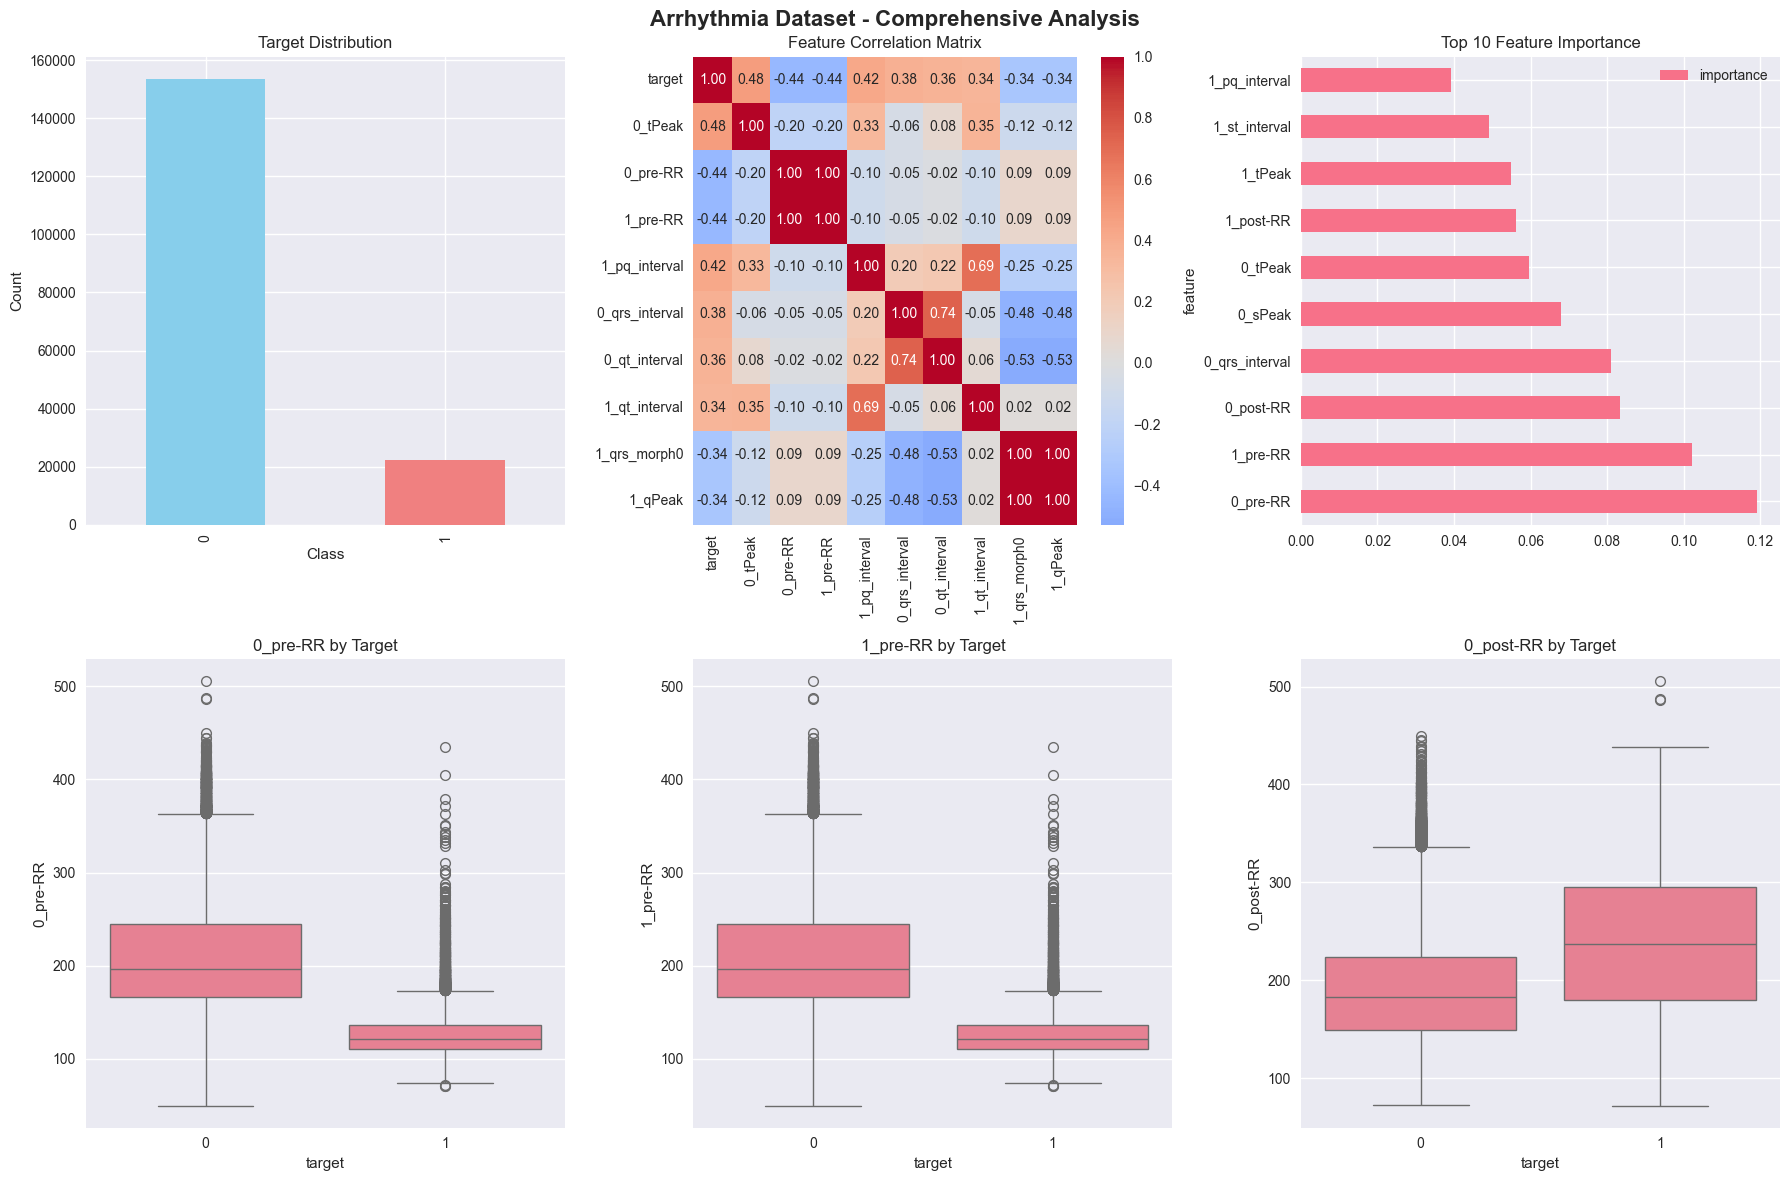

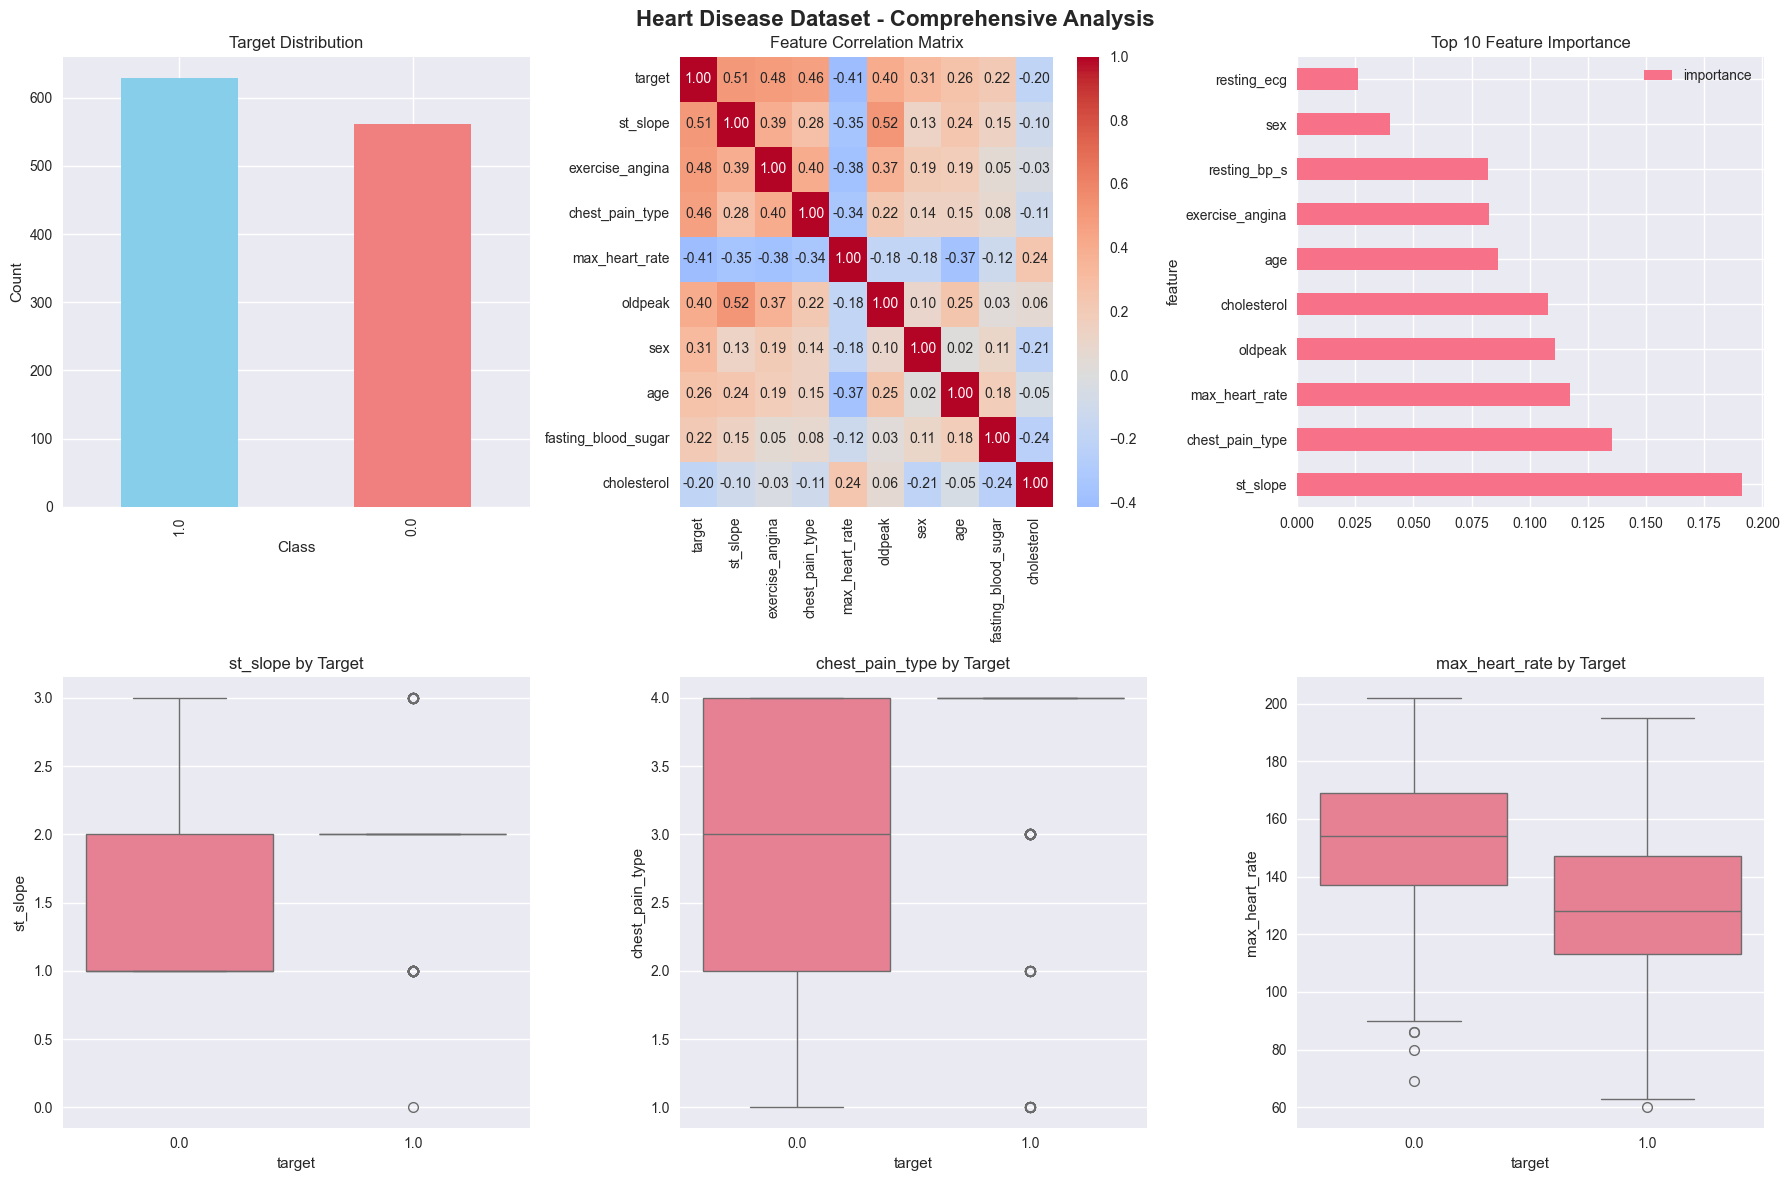

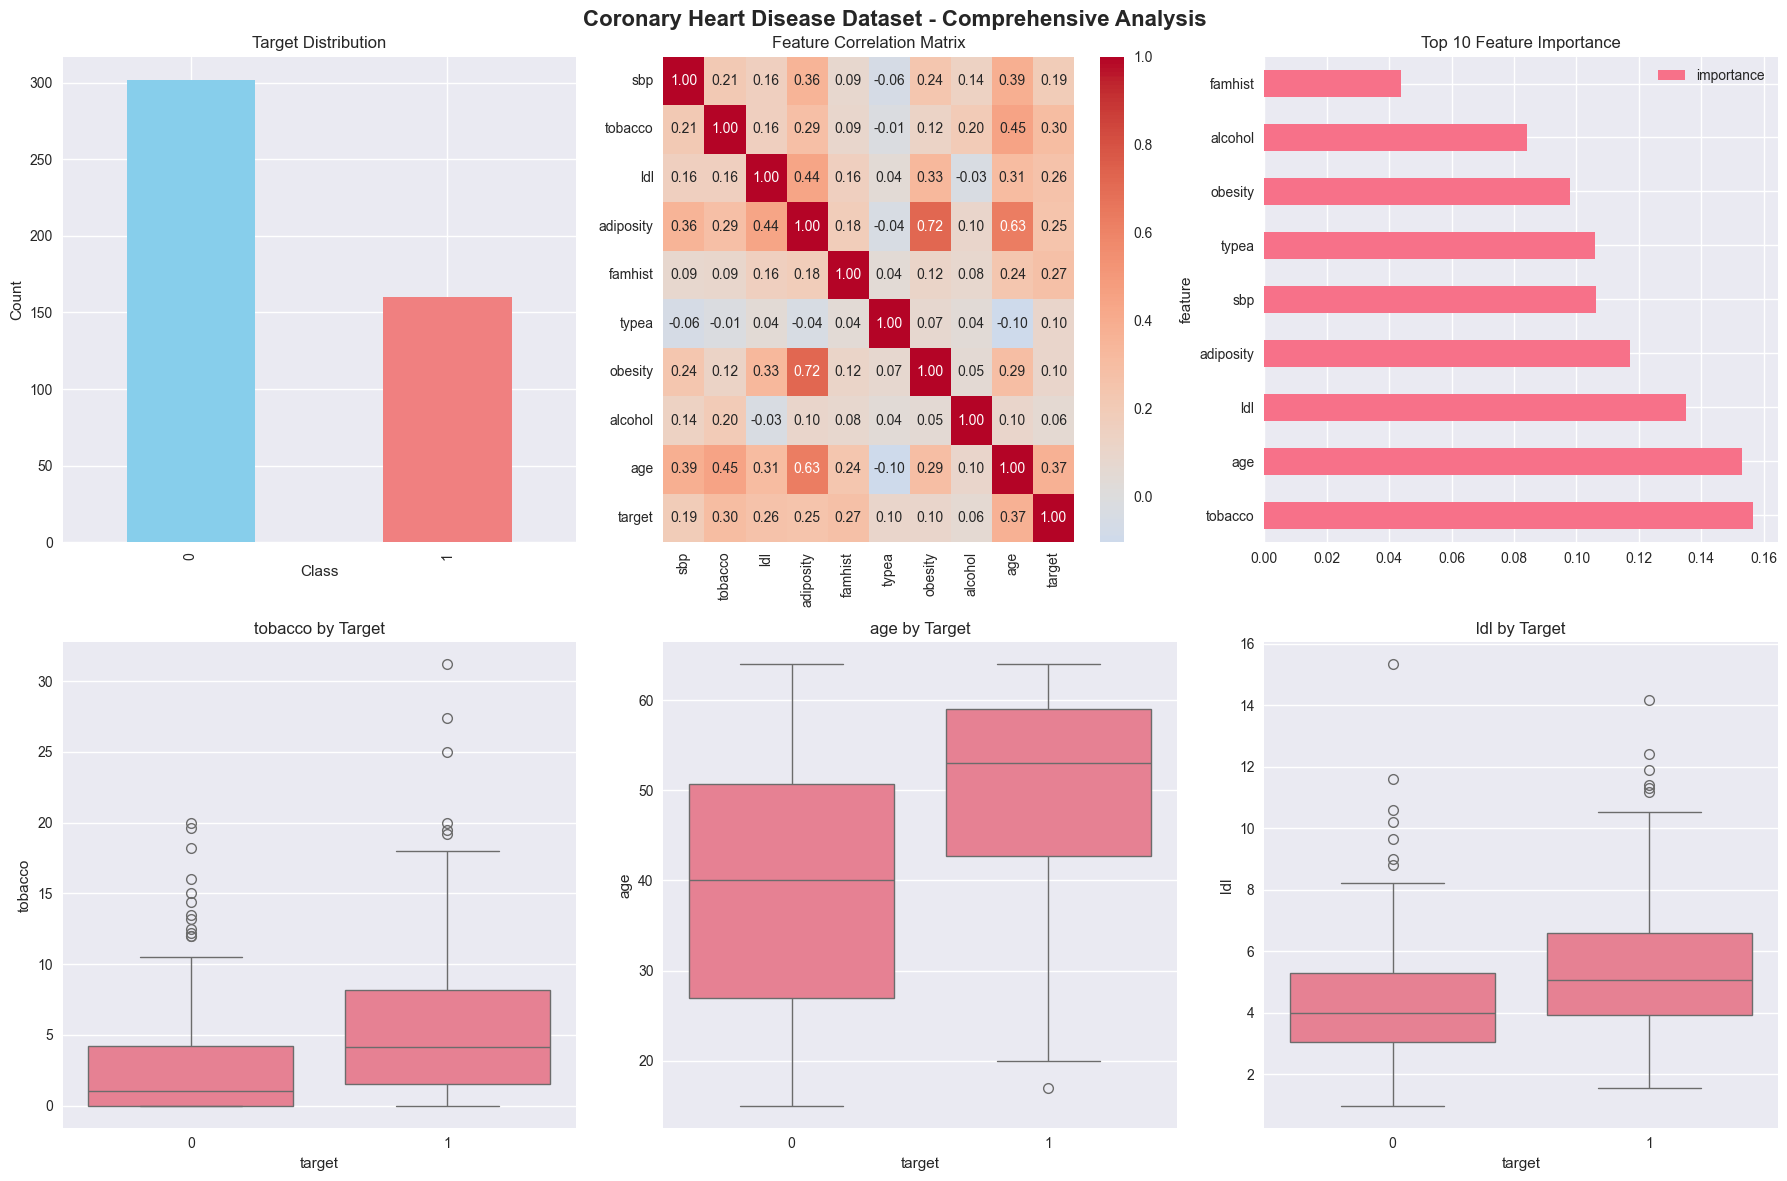

In [19]:
def create_comprehensive_visualizations(df, name, target_col='target'):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{name} Dataset - Comprehensive Analysis', fontsize=16, fontweight='bold')
    
    df[target_col].value_counts().plot(kind='bar', ax=axes[0,0], color=['skyblue', 'lightcoral'])
    axes[0,0].set_title('Target Distribution')
    axes[0,0].set_xlabel('Class')
    axes[0,0].set_ylabel('Count')
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 10:
        correlations = df[numeric_cols].corr()[target_col].abs().sort_values(ascending=False)
        top_features = correlations.head(10).index
        corr_matrix = df[top_features].corr()
    else:
        corr_matrix = df[numeric_cols].corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0,1], fmt='.2f')
    axes[0,1].set_title('Feature Correlation Matrix')
    
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False).head(10)
    
    feature_importance.plot(x='feature', y='importance', kind='barh', ax=axes[0,2])
    axes[0,2].set_title('Top 10 Feature Importance')
    
    top_3_features = feature_importance.head(3)['feature'].values
    
    for i, feature in enumerate(top_3_features):
        if i < 3:
            sns.boxplot(data=df, x=target_col, y=feature, ax=axes[1,i])
            axes[1,i].set_title(f'{feature} by Target')
    
    plt.tight_layout()
    plt.show()
    
    return feature_importance

print("\n📊 Creating Comprehensive Visualizations...")

arr_importance = create_comprehensive_visualizations(arrhythmia_processed, "Arrhythmia")
hd_importance = create_comprehensive_visualizations(heart_disease_processed, "Heart Disease")
chd_importance = create_comprehensive_visualizations(coronary_processed, "Coronary Heart Disease")

In [15]:
def train_and_evaluate_models(X, y, dataset_name):
    print(f"\n--- Training Models for {dataset_name} ---")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'SVM': SVC(random_state=42, probability=True),
        'KNN': KNeighborsClassifier(),
        'Naive Bayes': GaussianNB(),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1),
        'Neural Network': MLPClassifier(random_state=42, max_iter=1000)
    }
    
    results = {}
    cv_scores = {}
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, model in models.items():
        print(f"Training {name}...")
        
        if name in ['Logistic Regression', 'SVM', 'KNN', 'Neural Network']:
            X_train_model = X_train_scaled
            X_test_model = X_test_scaled
        else:
            X_train_model = X_train
            X_test_model = X_test
        
        cv_score = cross_val_score(model, X_train_model, y_train, cv=cv, scoring='roc_auc')
        cv_scores[name] = cv_score
        
        model.fit(X_train_model, y_train)
        y_pred = model.predict(X_test_model)
        y_pred_proba = model.predict_proba(X_test_model)[:, 1]
        
        results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba),
            'cv_mean': cv_score.mean(),
            'cv_std': cv_score.std()
        }
    
    return results, cv_scores, (X_train, X_test, y_train, y_test, scaler)

In [17]:
datasets = [
    (arrhythmia_processed, "Arrhythmia"),
    (heart_disease_processed, "Heart Disease"),
    (coronary_processed, "Coronary Heart Disease")
]

all_results = {}
all_cv_scores = {}
all_data = {}

for df, name in datasets:
    X = df.drop('target', axis=1)
    y = df['target']
    
    results, cv_scores, data = train_and_evaluate_models(X, y, name)
    all_results[name] = results
    all_cv_scores[name] = cv_scores
    all_data[name] = data


--- Training Models for Arrhythmia ---
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training KNN...
Training Naive Bayes...
Training Decision Tree...
Training XGBoost...
Training LightGBM...
Training Neural Network...

--- Training Models for Heart Disease ---
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training KNN...
Training Naive Bayes...
Training Decision Tree...
Training XGBoost...
Training LightGBM...
Training Neural Network...

--- Training Models for Coronary Heart Disease ---
Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training SVM...
Training KNN...
Training Naive Bayes...
Training Decision Tree...
Training XGBoost...
Training LightGBM...
Training Neural Network...


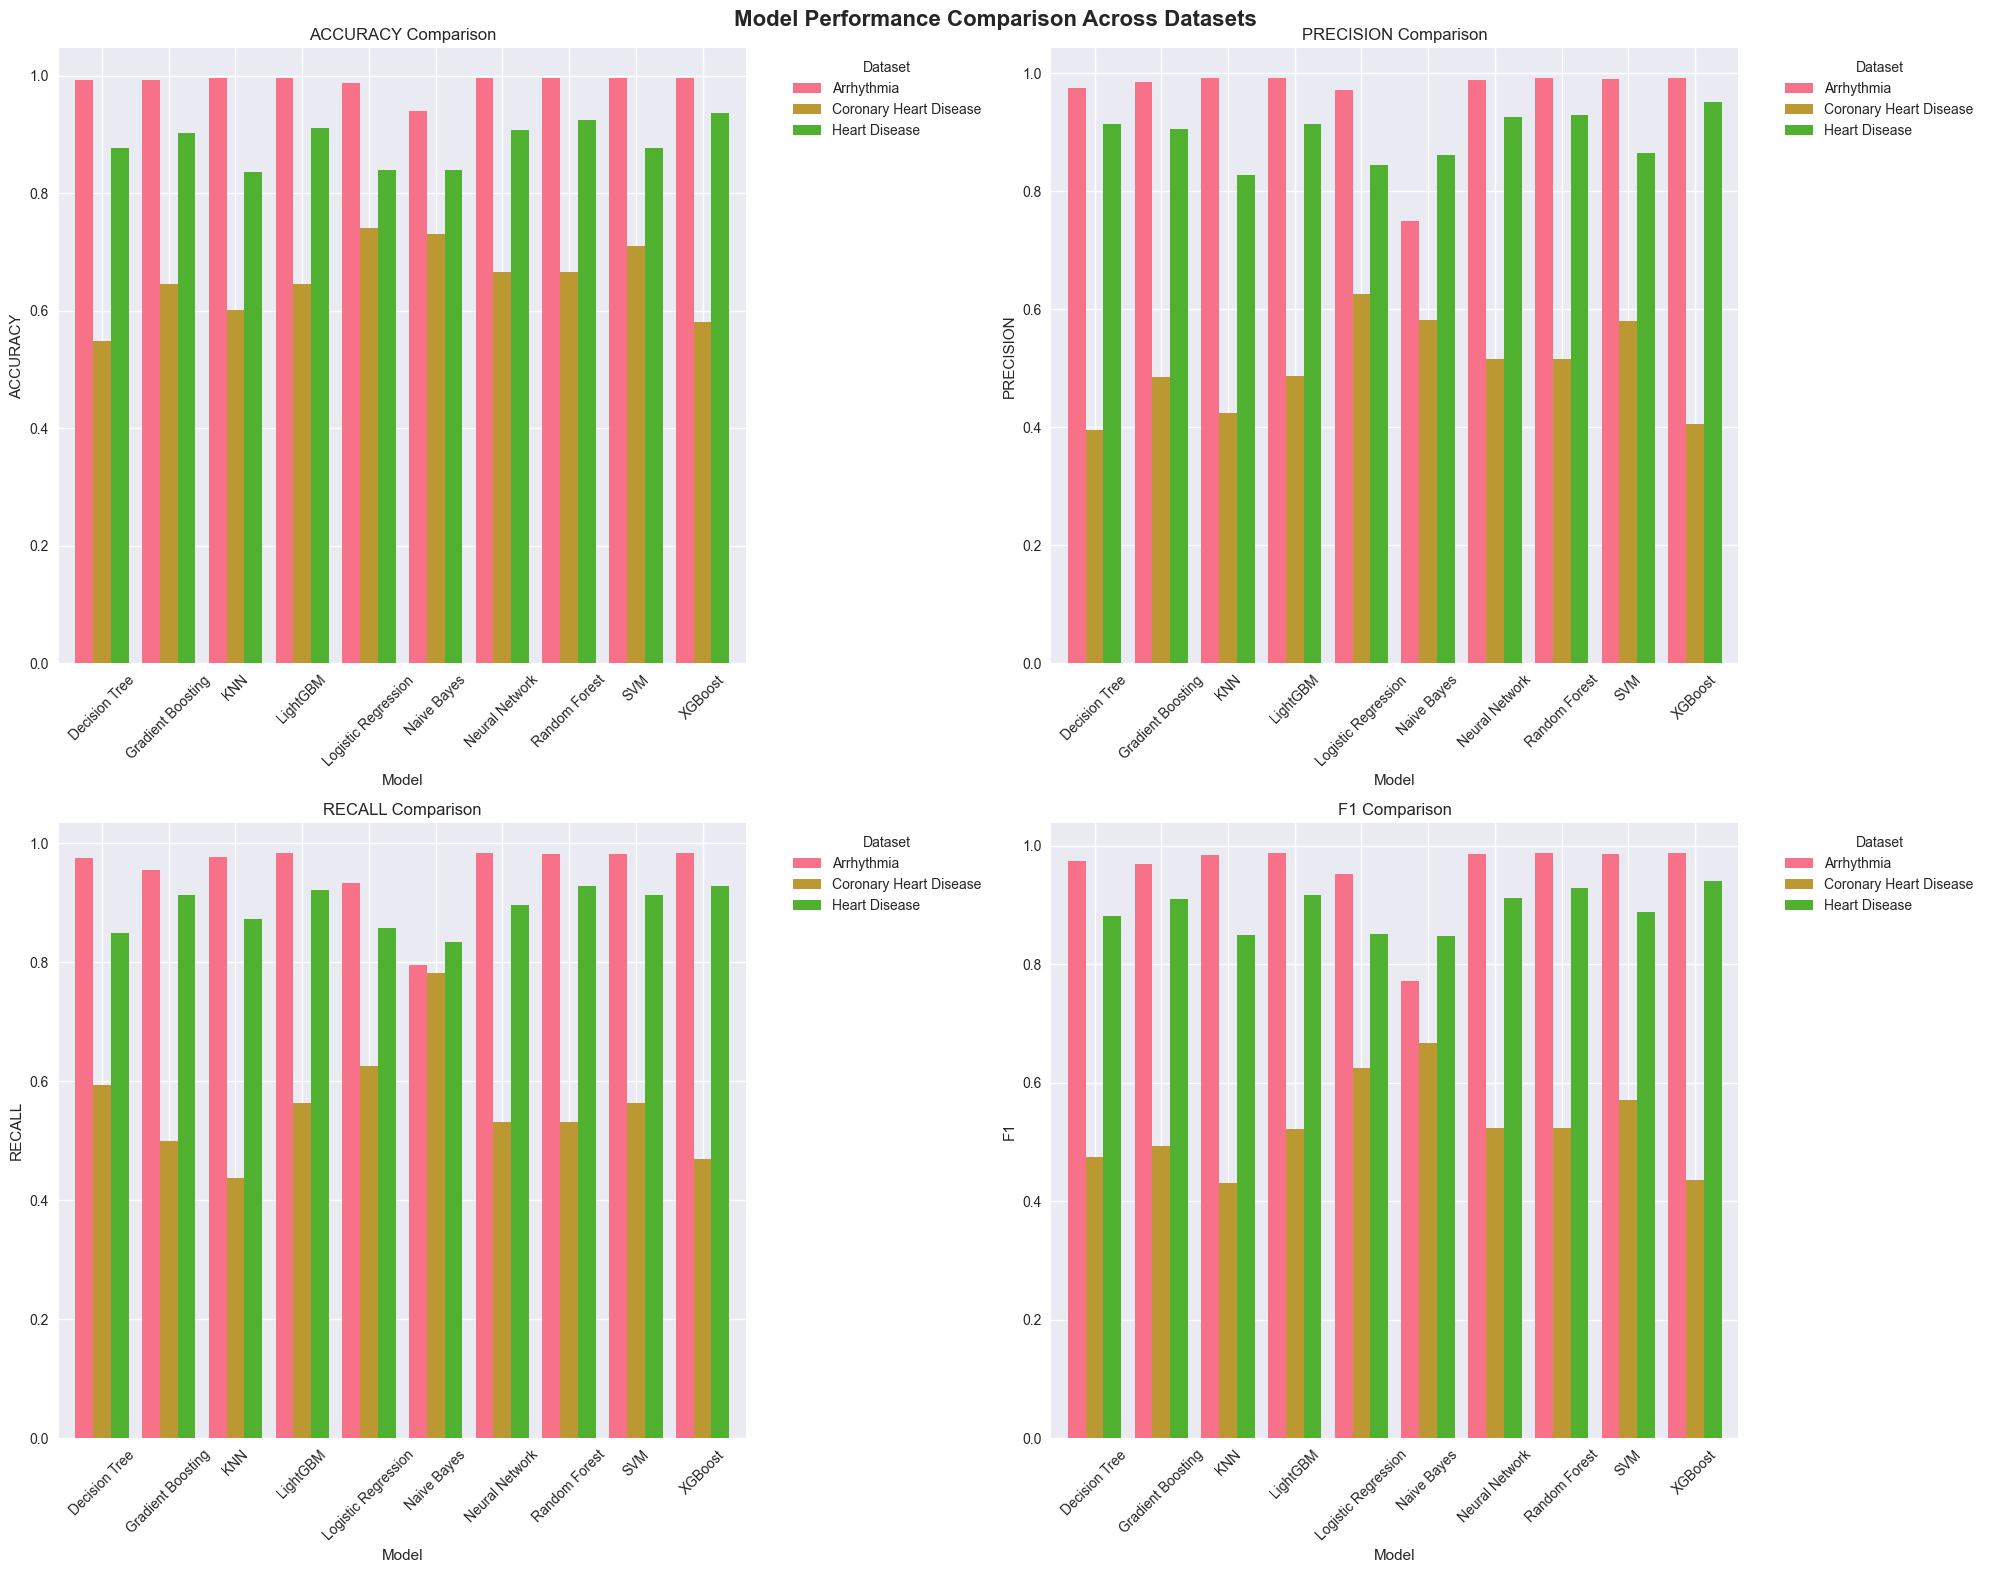

In [19]:
def create_results_visualization(all_results):
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Model Performance Comparison Across Datasets', fontsize=16, fontweight='bold')
    
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    
    for i, metric in enumerate(metrics[:4]):
        ax = axes[i//2, i%2]
        
        plot_data = []
        for dataset_name, results in all_results.items():
            for model_name, scores in results.items():
                plot_data.append({
                    'Dataset': dataset_name,
                    'Model': model_name,
                    'Score': scores[metric]
                })
        
        plot_df = pd.DataFrame(plot_data)
        
        # Create grouped bar plot
        pivot_df = plot_df.pivot(index='Model', columns='Dataset', values='Score')
        pivot_df.plot(kind='bar', ax=ax, width=0.8)
        ax.set_title(f'{metric.upper()} Comparison')
        ax.set_ylabel(metric.upper())
        ax.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

create_results_visualization(all_results)

In [21]:
for dataset_name, results in all_results.items():
    print(f"\n{dataset_name} Dataset Results:")
    print("-" * 50)
    
    results_df = pd.DataFrame(results).T
    results_df = results_df.round(4)
    results_df = results_df.sort_values('roc_auc', ascending=False)
    
    print(results_df.to_string())
    
    best_model = results_df.index[0]
    best_score = results_df.loc[best_model, 'roc_auc']
    print(f"\n🏆 Best Model: {best_model} (ROC-AUC: {best_score:.4f})")


Arrhythmia Dataset Results:
--------------------------------------------------
                     accuracy  precision  recall      f1  roc_auc  cv_mean  cv_std
XGBoost                0.9970     0.9920  0.9840  0.9880   0.9991   0.9996  0.0002
LightGBM               0.9968     0.9911  0.9833  0.9872   0.9988   0.9995  0.0001
Random Forest          0.9968     0.9923  0.9824  0.9873   0.9986   0.9992  0.0004
Neural Network         0.9964     0.9882  0.9835  0.9859   0.9983   0.9989  0.0004
SVM                    0.9965     0.9909  0.9815  0.9862   0.9981   0.9988  0.0004
Gradient Boosting      0.9925     0.9842  0.9556  0.9697   0.9970   0.9982  0.0006
KNN                    0.9962     0.9920  0.9775  0.9847   0.9944   0.9951  0.0007
Logistic Regression    0.9883     0.9723  0.9337  0.9526   0.9924   0.9932  0.0006
Decision Tree          0.9935     0.9745  0.9743  0.9744   0.9853   0.9857  0.0020
Naive Bayes            0.9406     0.7494  0.7960  0.7720   0.9629   0.9632  0.0007

🏆 Best

In [26]:
def optimize_hyperparameters(X, y, dataset_name):
    print(f"\nOptimizing hyperparameters for {dataset_name}...")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    param_grids = {
        'Random Forest': {
            'n_estimators': [100, 200, 300],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        },
        'XGBoost': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 6, 10],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        },
        'Gradient Boosting': {
            'n_estimators': [100, 200, 300],
            'max_depth': [3, 5, 7],
            'learning_rate': [0.01, 0.1, 0.2],
            'subsample': [0.8, 0.9, 1.0]
        }
    }
    
    models = {
        'Random Forest': RandomForestClassifier(random_state=42),
        'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }
    
    optimized_results = {}
    
    for name, model in models.items():
        print(f"  Optimizing {name}...")
        
        X_train_model = X_train_scaled if name in ['Logistic Regression', 'SVM'] else X_train
        X_test_model = X_test_scaled if name in ['Logistic Regression', 'SVM'] else X_test
        
        grid_search = GridSearchCV(
            model, 
            param_grids[name], 
            cv=3, 
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train_model, y_train)
        
        best_model = grid_search.best_estimator_
        y_pred = best_model.predict(X_test_model)
        y_pred_proba = best_model.predict_proba(X_test_model)[:, 1]
        
        optimized_results[name] = {
            'best_params': grid_search.best_params_,
            'best_score': grid_search.best_score_,
            'test_accuracy': accuracy_score(y_test, y_pred),
            'test_roc_auc': roc_auc_score(y_test, y_pred_proba),
            'model': best_model
        }
    
    return optimized_results

optimized_results = {}
for df, name in datasets:
    X = df.drop('target', axis=1)
    y = df['target']
    optimized_results[name] = optimize_hyperparameters(X, y, name)



Optimizing hyperparameters for Arrhythmia...
  Optimizing Random Forest...
  Optimizing XGBoost...
  Optimizing Gradient Boosting...

Optimizing hyperparameters for Heart Disease...
  Optimizing Random Forest...
  Optimizing XGBoost...
  Optimizing Gradient Boosting...

Optimizing hyperparameters for Coronary Heart Disease...
  Optimizing Random Forest...
  Optimizing XGBoost...
  Optimizing Gradient Boosting...


In [28]:
print("\n🎯 Hyperparameter Optimization Results:")
print("=" * 60)

for dataset_name, results in optimized_results.items():
    print(f"\n{dataset_name} Dataset - Optimized Models:")
    print("-" * 40)
    
    for model_name, result in results.items():
        print(f"\n{model_name}:")
        print(f"  Best CV Score: {result['best_score']:.4f}")
        print(f"  Test ROC-AUC: {result['test_roc_auc']:.4f}")
        print(f"  Test Accuracy: {result['test_accuracy']:.4f}")
        print(f"  Best Parameters: {result['best_params']}")


🎯 Hyperparameter Optimization Results:

Arrhythmia Dataset - Optimized Models:
----------------------------------------

Random Forest:
  Best CV Score: 0.9996
  Test ROC-AUC: 0.9990
  Test Accuracy: 0.9966
  Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}

XGBoost:
  Best CV Score: 0.9996
  Test ROC-AUC: 0.9992
  Test Accuracy: 0.9973
  Best Parameters: {'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1.0}

Gradient Boosting:
  Best CV Score: 0.9992
  Test ROC-AUC: 0.9983
  Test Accuracy: 0.9965
  Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}

Heart Disease Dataset - Optimized Models:
----------------------------------------

Random Forest:
  Best CV Score: 0.9424
  Test ROC-AUC: 0.9746
  Test Accuracy: 0.9244
  Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

XGBoost:
  Best CV Score: 0.9414
  Test 

In [30]:
def create_deep_learning_model(input_dim, model_type='standard'):
    if model_type == 'standard':
        model = keras.Sequential([
            layers.Dense(128, activation='relu', input_shape=(input_dim,)),
            layers.Dropout(0.3),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(1, activation='sigmoid')
        ])
    elif model_type == 'deep':
        model = keras.Sequential([
            layers.Dense(256, activation='relu', input_shape=(input_dim,)),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(32, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(1, activation='sigmoid')
        ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )
    
    return model

In [32]:
def train_deep_learning_models(X, y, dataset_name):
    print(f"\nTraining Deep Learning models for {dataset_name}...")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {
        'Standard DNN': create_deep_learning_model(X_train_scaled.shape[1], 'standard'),
        'Deep DNN': create_deep_learning_model(X_train_scaled.shape[1], 'deep')
    }
    
    dl_results = {}
    
    for name, model in models.items():
        print(f"  Training {name}...")
        
        early_stopping = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )
        
        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.2, patience=5, min_lr=0.001
        )
        
        history = model.fit(
            X_train_scaled, y_train,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping, reduce_lr],
            verbose=0
        )
        
        y_pred_proba = model.predict(X_test_scaled).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)
        
        dl_results[name] = {
            'accuracy': accuracy_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'history': history.history
        }
    
    return dl_results

In [34]:
dl_results = {}
for df, name in datasets:
    X = df.drop('target', axis=1)
    y = df['target']
    dl_results[name] = train_deep_learning_models(X, y, name)


Training Deep Learning models for Arrhythmia...
  Training Standard DNN...
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 937us/step
  Training Deep DNN...
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

Training Deep Learning models for Heart Disease...
  Training Standard DNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
  Training Deep DNN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Training Deep Learning models for Coronary Heart Disease...
  Training Standard DNN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
  Training Deep DNN...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


In [36]:
for dataset_name, results in dl_results.items():
    print(f"\n{dataset_name} Dataset:")
    print("-" * 30)
    
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  ROC-AUC: {metrics['roc_auc']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1-Score: {metrics['f1']:.4f}")


Arrhythmia Dataset:
------------------------------

Standard DNN:
  Accuracy: 0.9969
  ROC-AUC: 0.9988
  Precision: 0.9905
  Recall: 0.9847
  F1-Score: 0.9876

Deep DNN:
  Accuracy: 0.9966
  ROC-AUC: 0.9988
  Precision: 0.9914
  Recall: 0.9817
  F1-Score: 0.9865

Heart Disease Dataset:
------------------------------

Standard DNN:
  Accuracy: 0.8445
  ROC-AUC: 0.9271
  Precision: 0.8450
  Recall: 0.8651
  F1-Score: 0.8549

Deep DNN:
  Accuracy: 0.8866
  ROC-AUC: 0.9330
  Precision: 0.9091
  Recall: 0.8730
  F1-Score: 0.8907

Coronary Heart Disease Dataset:
------------------------------

Standard DNN:
  Accuracy: 0.7312
  ROC-AUC: 0.7961
  Precision: 0.5946
  Recall: 0.6875
  F1-Score: 0.6377

Deep DNN:
  Accuracy: 0.6989
  ROC-AUC: 0.7772
  Precision: 0.7000
  Recall: 0.2188
  F1-Score: 0.3333


In [38]:
def create_ensemble_model(X, y, dataset_name):
    print(f"\nCreating ensemble for {dataset_name}...")
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
    xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
    
    ensemble = VotingClassifier(
        estimators=[
            ('rf', rf),
            ('xgb', xgb_model),
            ('gb', gb)
        ],
        voting='soft'
    )
    
    ensemble.fit(X_train, y_train)
    
    y_pred = ensemble.predict(X_test)
    y_pred_proba = ensemble.predict_proba(X_test)[:, 1]
    
    ensemble_results = {
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    
    return ensemble_results, ensemble

In [40]:
ensemble_results = {}
ensemble_models = {}

for df, name in datasets:
    X = df.drop('target', axis=1)
    y = df['target']
    results, model = create_ensemble_model(X, y, name)
    ensemble_results[name] = results
    ensemble_models[name] = model


Creating ensemble for Arrhythmia...

Creating ensemble for Heart Disease...

Creating ensemble for Coronary Heart Disease...


In [42]:
for dataset_name, results in ensemble_results.items():
    print(f"\n{dataset_name} Ensemble:")
    print("-" * 25)
    for metric, value in results.items():
        print(f"  {metric.upper()}: {value:.4f}")


Arrhythmia Ensemble:
-------------------------
  ACCURACY: 0.9968
  ROC_AUC: 0.9991
  PRECISION: 0.9918
  RECALL: 0.9826
  F1: 0.9872

Heart Disease Ensemble:
-------------------------
  ACCURACY: 0.9244
  ROC_AUC: 0.9727
  PRECISION: 0.9426
  RECALL: 0.9127
  F1: 0.9274

Coronary Heart Disease Ensemble:
-------------------------
  ACCURACY: 0.6667
  ROC_AUC: 0.7054
  PRECISION: 0.5161
  RECALL: 0.5000
  F1: 0.5079


In [46]:
for dataset_name in all_results.keys():
    best_ml = max(all_results[dataset_name].items(), key=lambda x: x[1]['roc_auc'])
    best_dl = max(dl_results[dataset_name].items(), key=lambda x: x[1]['roc_auc'])
    ensemble_perf = ensemble_results[dataset_name]['roc_auc']
    ensemble_acc = ensemble_results[dataset_name]['accuracy']
    
    print(f"\n{dataset_name}:")
    print(f"  Best ML Model: {best_ml[0]} (ROC-AUC: {best_ml[1]['roc_auc']:.4f}, Accuracy: {best_ml[1]['accuracy']:.4f})")
    print(f"  Best DL Model: {best_dl[0]} (ROC-AUC: {best_dl[1]['roc_auc']:.4f}, Accuracy: {best_dl[1]['accuracy']:.4f})")
    print(f"  Ensemble Model: ROC-AUC: {ensemble_perf:.4f}, Accuracy: {ensemble_acc:.4f}")
    
    best_overall = max([
        ('ML: ' + best_ml[0], best_ml[1]['roc_auc'], best_ml[1]['accuracy']),
        ('DL: ' + best_dl[0], best_dl[1]['roc_auc'], best_dl[1]['accuracy']),
        ('Ensemble', ensemble_perf, ensemble_acc)
    ], key=lambda x: x[1])  

    print(f"  🏆 BEST OVERALL: {best_overall[0]} (ROC-AUC: {best_overall[1]:.4f}, Accuracy: {best_overall[2]:.4f})")


Arrhythmia:
  Best ML Model: XGBoost (ROC-AUC: 0.9991, Accuracy: 0.9970)
  Best DL Model: Standard DNN (ROC-AUC: 0.9988, Accuracy: 0.9969)
  Ensemble Model: ROC-AUC: 0.9991, Accuracy: 0.9968
  🏆 BEST OVERALL: Ensemble (ROC-AUC: 0.9991, Accuracy: 0.9968)

Heart Disease:
  Best ML Model: XGBoost (ROC-AUC: 0.9717, Accuracy: 0.9370)
  Best DL Model: Deep DNN (ROC-AUC: 0.9330, Accuracy: 0.8866)
  Ensemble Model: ROC-AUC: 0.9727, Accuracy: 0.9244
  🏆 BEST OVERALL: Ensemble (ROC-AUC: 0.9727, Accuracy: 0.9244)

Coronary Heart Disease:
  Best ML Model: Logistic Regression (ROC-AUC: 0.8176, Accuracy: 0.7419)
  Best DL Model: Standard DNN (ROC-AUC: 0.7961, Accuracy: 0.7312)
  Ensemble Model: ROC-AUC: 0.7054, Accuracy: 0.6667
  🏆 BEST OVERALL: ML: Logistic Regression (ROC-AUC: 0.8176, Accuracy: 0.7419)


In [54]:
import pickle
import os

os.makedirs('heart', exist_ok=True)

def save_model(model, scaler, model_name, dataset_name):
    with open(f'heart/{dataset_name.lower().replace(" ", "_")}_{model_name}.pkl', 'wb') as f:
        pickle.dump(model, f)
    
    if scaler:
        with open(f'heart/{dataset_name.lower().replace(" ", "_")}_scaler.pkl', 'wb') as f:
            pickle.dump(scaler, f)

In [56]:
save_model(ensemble_models["Arrhythmia"], None, 'ensemble', 'Arrhythmia')
print("✅ Saved Arrhythmia Ensemble model")

save_model(ensemble_models["Heart Disease"], None, 'ensemble', 'Heart Disease')
print("✅ Saved Heart Disease Ensemble model")

✅ Saved Arrhythmia Ensemble model
✅ Saved Heart Disease Ensemble model


In [58]:
X_train_chd = all_data["Coronary Heart Disease"][0]
X_test_chd = all_data["Coronary Heart Disease"][1]
y_train_chd = all_data["Coronary Heart Disease"][2]
y_test_chd = all_data["Coronary Heart Disease"][3]
scaler_chd = all_data["Coronary Heart Disease"][4]

X_train_chd_scaled = scaler_chd.transform(X_train_chd)
X_test_chd_scaled = scaler_chd.transform(X_test_chd)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 500, 1000]
}

lr = LogisticRegression(random_state=42)
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train_chd_scaled, y_train_chd)

best_lr = grid_search.best_estimator_

y_pred = best_lr.predict(X_test_chd_scaled)
y_pred_proba = best_lr.predict_proba(X_test_chd_scaled)[:, 1]

print("\n=== Optimized Logistic Regression Results ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Test ROC-AUC: {roc_auc_score(y_test_chd, y_pred_proba):.4f}")
print(f"Accuracy: {accuracy_score(y_test_chd, y_pred):.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits

=== Optimized Logistic Regression Results ===
Best Parameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Test ROC-AUC: 0.8186
Accuracy: 0.7527


In [60]:
with open('heart/coronary_lr_optimized.pkl', 'wb') as f:
    pickle.dump({
        'model': best_lr,
        'scaler': scaler_chd,
        'best_params': grid_search.best_params_,
        'test_metrics': {
            'roc_auc': roc_auc_score(y_test_chd, y_pred_proba),
            'accuracy': accuracy_score(y_test_chd, y_pred),
            'classification_report': classification_report(y_test_chd, y_pred)
        }
    }, f)
print("✅ Saved optimized Logistic Regression model with metadata")

✅ Saved optimized Logistic Regression model with metadata
